# SparsePEA — Tutorial

**Simon Mishricky**

This notebook walks through the `sparsepea` package by solving two workhorse
macroeconomic models that feature occasionally binding constraints:

1. **Real Business Cycle (RBC)** with irreversible investment
2. **Diamond–Mortensen–Pissarides (DMP)** search-and-matching model

Both are solved using the Parameterised Expectations Algorithm (PEA) on
Tasmanian sparse grids — a combination that scales well to higher dimensions
and handles non-differentiable kinks in the policy function without
requiring smoothing or penalty methods.

## Background

### Why PEA?

Many DSGE models contain Euler equations of the form

$$g(x_t) = \mathbb{E}_t\bigl[h(x_t, x_{t+1})\bigr]$$

where the right-hand side involves a conditional expectation that cannot be
evaluated in closed form. Perturbation methods linearise or take low-order
Taylor expansions around a steady state, which works well when the model is
smooth but breaks down near occasionally binding constraints — the kink
introduced by a constraint like $K' \geq (1-\delta)K$ makes the policy
function non-differentiable, so local approximations miss the binding region
entirely.

The **Parameterised Expectations Algorithm** (PEA) avoids this problem by
working with a global approximation. Rather than expanding around a single
point, the PEA parameterises the conditional expectation itself:

$$\psi(x_t) \approx \mathbb{E}_t\bigl[h(x_t, x_{t+1})\bigr]$$

and iterates on the functional equation until $\psi$ converges. At each
iteration, complementarity conditions (e.g. the KKT conditions for
irreversible investment) are checked pointwise, so the constraint can bind
at some grid points and not others — no smoothing is needed.

### Why sparse grids?

The PEA requires evaluating and updating $\psi$ on a grid of state-space
points. With a standard tensor-product grid, the number of points grows
exponentially in the number of state variables — a phenomenon known as the
*curse of dimensionality*. For a grid with $n$ points per dimension and $d$
dimensions, a tensor grid has $n^d$ points: manageable when $d = 2$, but
infeasible for the $d = 4$ or $d = 5$ models that arise in applied work.

Sparse grids (Smolyak, 1963) break this curse by retaining only the grid
points that contribute the most to interpolation accuracy. The result is a
grid whose size grows *polynomially* rather than exponentially in $d$.
SparsePEA uses the [Tasmanian](https://tasmanian.ornl.gov/) library from
Oak Ridge National Laboratory, which provides local polynomial sparse grids
for both interpolation and numerical integration (quadrature).

In [1]:
import numpy as np
import quantecon.markov as qe
from sparsepea.models import rbc_jit, dmp_jit
from sparsepea.tools import tools

## Initial guess

Every fixed-point iteration needs a starting point. For the PEA, we need an
initial guess of the expectation function $\psi(\mathbf{s})$ evaluated at
each node of the sparse grid.

A good heuristic is to use the *certainty-equivalent* (perfect-foresight)
solution: set the shock to its unconditional mean and solve the resulting
deterministic Euler equation analytically. For the RBC model this yields a
log-linear guess in $(K, Z)$; for the DMP model a simple linear guess in
$(N, X)$ suffices. In both cases the algorithm converges from these starting
points in well under a hundred iterations.

In [2]:
# Parameters for initial guess function
α = 0.33          
δ = 0.025 
y_k = 0.11210762331838565
β = 1.0 / (α * y_k + 1.0 - δ)

# Coefficients for initial guess
γ_rbc = np.array([-np.log(1 - α * β) , -α, -1])

In [3]:
# Function for initial guess
def initial_guess(grid_states, γ):
    
    grid_size = grid_states[:, 1].size
    guess = np.zeros([grid_size, 1])
    
    for i in range(grid_size):
        
        state = grid_states[i, :]
        x, y = state[0], state[1]
        
        guess[i, :] = np.exp(γ[0] + γ[1] * np.log(x) + γ[2] * np.log(y))
        
    return guess

## 1. Real Business Cycle with Irreversible Investment

### The model

The RBC model with irreversible investment is one of the simplest settings
in which an occasionally binding constraint matters quantitatively. A social
planner chooses a sequence of capital stocks to maximise discounted lifetime
utility:

$$v(K, Z) = \max_{K' \in \mathcal{D}_{K,Z}}\; u(C) + \beta\, \mathbb{E}\!\left[v(K', Z') \mid Z\right]$$

subject to a resource constraint and a non-negativity constraint on gross
investment:

$$C = Z K^\alpha + (1-\delta) K - K', \qquad
K' \geq (1-\delta) K$$

Total factor productivity (TFP) follows a log-AR(1) process:

$$\ln Z' = \rho \ln Z + \sigma\varepsilon', \qquad \varepsilon' \sim N(0,1)$$

with CRRA preferences $u(C) = \frac{C^{1-\eta}-1}{1-\eta}$.

### Euler equation and complementarity conditions

Taking first-order conditions and letting $\mu \geq 0$ denote the KKT
multiplier on the irreversibility constraint yields:

$$C^{-\eta} - \mu
= \beta\, \mathbb{E}\!\left[
  C'^{-\eta}\bigl(1 - \delta + \alpha Z' K'^{\alpha-1}\bigr)
  - \mu'(1-\delta)
\right]$$

with the complementary slackness conditions

$$\mu \geq 0, \qquad K' - (1-\delta)K \geq 0, \qquad \mu\bigl[K' - (1-\delta)K\bigr] = 0.$$

These conditions partition the state space into two regions. In the *interior*
region, the constraint does not bind ($\mu = 0$) and the planner freely
chooses investment. In the *constrained* region, gross investment is zero
($K' = (1-\delta)K$), the household consumes all output ($C = ZK^\alpha$),
and $\mu > 0$ captures the shadow value of the binding constraint.

The PEA parameterises the right-hand side of the Euler equation as
$\psi(K, Z)$ and iterates until convergence. At each grid point the
algorithm checks whether the implied $K'$ violates the irreversibility
constraint and enforces the appropriate complementarity condition.

In [4]:
# Initialise an instance of the rbc model
rbc_model = rbc_jit()

# Initialise tools class given the rbc model
tool_box = tools(model=rbc_model)

# Make a sparse grid require to generate an initial guess
# These grids as well as all grids used in this notebook are order=8, depth=1, see Tasmanian
grid, grid_states = tool_box.make_states_grid()

# Generate an initial guess
e = initial_guess(grid_states, γ_rbc)

# Solve for the optimal Euler equation and consumption function
e_p, c, μ, count= tool_box.compute_solution(e)
print(count)

Convergence successful: 318 Iterations


In [5]:
%%timeit
e_p, c, μ, count = tool_box.compute_solution(e)

1min 26s ± 260 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Performance comparison

The table below compares solve times across three different code structures.
The `numba.jitclass` approach used by `sparsepea.models` is somewhat slower
than a flat `@njit` implementation because `jitclass` is still experimental
and does not support `numba.prange` for parallelisation. However, it is
dramatically faster than pure Python, and the object-oriented interface
makes the code modular and extensible.

|    Structure   | PEA algorithm |
|:-----:|:---------:|
|   `njit` + `prange` | 53.6 sec  |
| `jitclass` (this package) | 1 min 20 sec |
| no `numba` | 32 min 5 sec |

### Visualising the solution

The 3D surface below shows the consumption policy function $C(K, Z)$
interpolated onto a regular grid, with the sparse grid nodes overlaid as
black dots. The surface is smooth in the interior region but exhibits a kink
along the boundary where the irreversibility constraint binds — this is
exactly the non-linearity that perturbation methods struggle to capture.

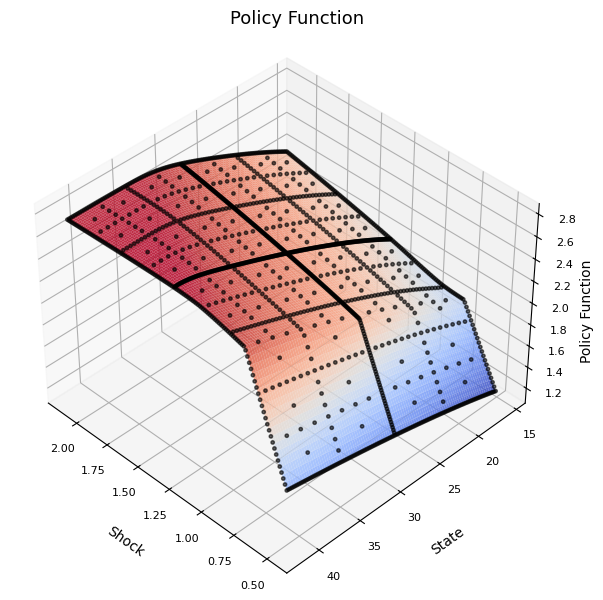

In [6]:
tool_box.plot_policy_3d(c)

### Solution accuracy

A key advantage of projection methods like the PEA is that solution accuracy
can be assessed directly via **Euler equation residuals**. If the solution
were exact, the Euler equation would hold with zero error at every point in
the state space. In practice, we compute

$$\varepsilon(K, Z) = \left|\frac{C(K,Z) - C^{\text{implied}}(K,Z)}{C^{\text{implied}}(K,Z)}\right|$$

where $C^{\text{implied}}$ is the consumption level implied by the converged
expectation function. Residuals below $10^{-3}$ (0.1%) are generally
considered acceptable in the computational economics literature; below
$10^{-4}$ is very good.

The 3D surface shows residuals across the state space, while the histogram
gives a sense of the overall distribution. Residuals are typically largest
near the boundary of the binding region, where the policy function is
least smooth.

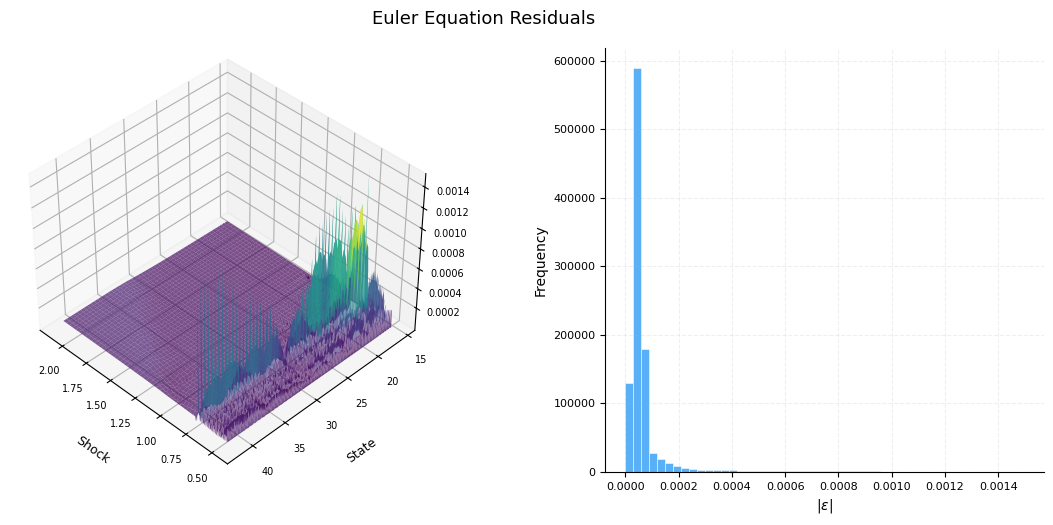

In [7]:
tool_box.plot_errors_3d(e)

## 2. Diamond–Mortensen–Pissarides (Hagedorn–Manovskii)

### The model

The DMP model is the canonical framework for analysing equilibrium
unemployment. Firms post vacancies at a cost, unemployed workers search for
jobs, and a matching function governs the rate at which vacancies and
searchers meet. The Hagedorn and Manovskii (2008) calibration is notable
for generating realistic labour-market volatility — the so-called *Shimer
puzzle* — by setting the flow value of unemployment $b$ close to average
productivity.

### Free-entry condition

Firms post vacancies until the expected cost equals the expected value of a
filled job. The resulting free-entry condition is

$$\frac{\kappa_t}{q(\theta_t)} - \lambda_t
= \beta\, \mathbb{E}\!\left[
  X_{t+1} - W_{t+1}
  + (1-s)\!\left(\frac{\kappa_{t+1}}{q(\theta_{t+1})} - \lambda_{t+1}\right)
\right]$$

where $\theta_t = V_t / (1-N_t)$ is labour-market tightness (the
vacancy–unemployment ratio), $q(\theta_t)$ is the vacancy-filling rate from
a CES matching function, $s$ is the exogenous separation rate, and wages
are Nash-bargained:

$$W_t = \eta\bigl(X_t + \kappa_t\theta_t\bigr) + (1-\eta)\, b$$

The vacancy cost $\kappa_t = \kappa_K X_t + \kappa_W X_t^\xi$ is
state-dependent (increasing in productivity), and $\ln X_{t+1} = \rho \ln X_t +
\sigma\varepsilon_{t+1}$.

### Complementarity conditions

As in the RBC model, there is an occasionally binding constraint: firms
cannot post negative vacancies. When productivity is sufficiently low, no
vacancies are posted ($V_t = 0$, $\theta_t = 0$) and the multiplier
$\lambda_t > 0$ captures the shadow cost of the binding constraint:

$$\lambda_t \geq 0, \qquad q(\theta_t)\, V_t \geq 0, \qquad
\lambda_t\, q(\theta_t)\, V_t = 0$$

This zero-vacancy region is economically important: it corresponds to
episodes in which the labour market is so weak that firms find it
unprofitable to recruit at all.

In [8]:
γ_dmp = np.array([-20, 23.18875328038525, 0.0])

In [9]:
def initial_guess_dmp(grid_states, γ):
    
    grid_size = grid_states[:, 1].size
    guess = np.zeros([grid_size, 1])
    
    for i in range(grid_size):
        
        state = grid_states[i, :]
        x, y = state[0], state[1]
        
        guess[i, :] = γ[0] + γ[1] * x + γ[2] * y
        
    return guess

In [10]:
# Initialise an instance of the dmp model
dmp_model = dmp_jit()

# Initialise tools class given the dmp model
tool_box = tools(model=dmp_model, max_iter=1000)
grid_dmp, grid_states_dmp = tool_box.make_states_grid()

# Make a sparse grid require to generate an initial guess
e_dmp = initial_guess_dmp(grid_states_dmp, γ_dmp)

# Solve for the optimal Euler equation and tightness function
e_p, θ, λ, count_dmp = tool_box.compute_solution(e_dmp)
print(count_dmp)

Convergence successful: 521 Iterations


In [11]:
%%timeit
e_p, θ, μ, count_dmp = tool_box.compute_solution(e_dmp)

2min 21s ± 507 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Policy function

The surface below shows labour-market tightness $\theta(N, X)$ as a function
of the two state variables (employment $N$ and productivity $X$). Higher
productivity and lower employment both increase tightness — firms post more
vacancies when output per worker is high and when the pool of available
workers is large.

The flat region at $\theta = 0$ corresponds to the zero-vacancy constraint
binding: when productivity is very low, no vacancies are posted and the
labour market is completely slack.

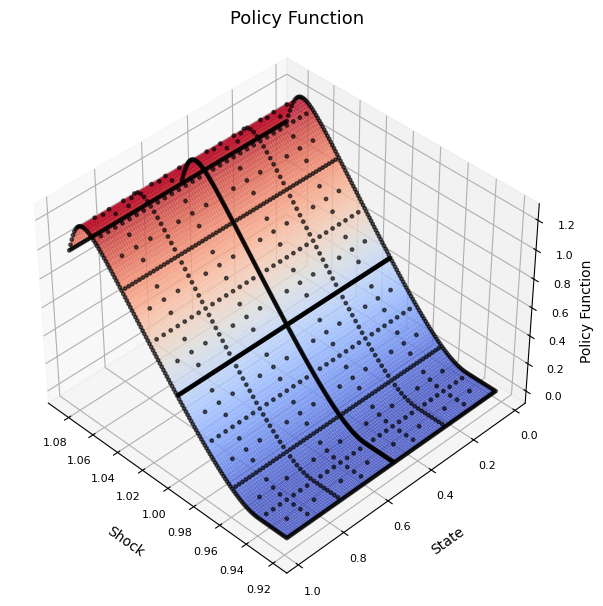

In [12]:
tool_box.plot_policy_3d(θ)

### Euler residuals

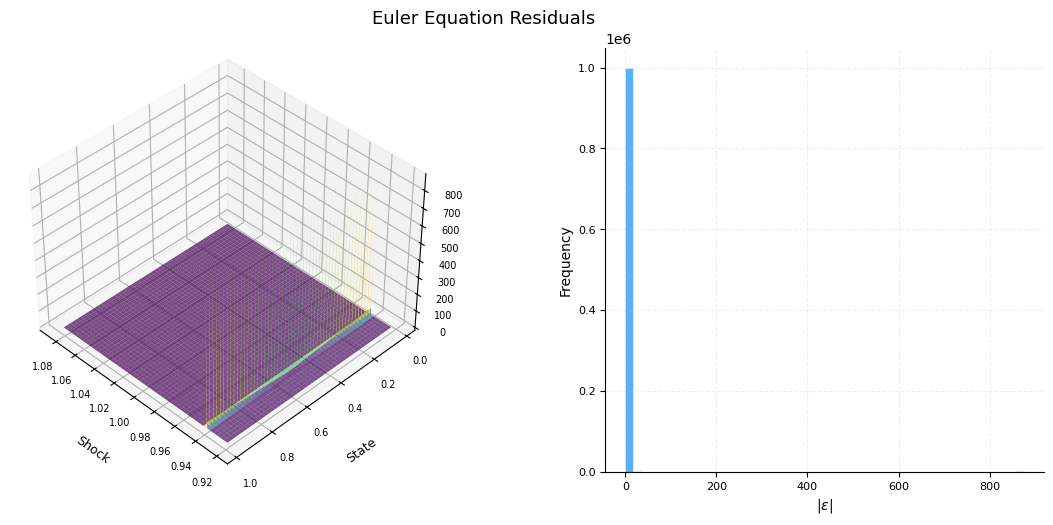

In [13]:
tool_box.plot_errors_3d(e_dmp)

## Summary

This notebook demonstrated the core workflow of the `sparsepea` package:

1. **Specify the model** by instantiating a JIT-compiled model class.
2. **Build the sparse grid** — a single call determines the grid nodes and
   quadrature weights.
3. **Solve** via PEA fixed-point iteration, with complementarity conditions
   checked pointwise at each step.
4. **Diagnose** solution quality through Euler equation residuals.

The same interface generalises to any model that can be cast in the form
$\psi(\mathbf{s}) = \mathbb{E}[h(\mathbf{s}, \mathbf{s}')]$ with
complementarity conditions. Adding a new model amounts to writing a
`@jitclass` that implements `x_axis_grid`, `rhs_euler`, `c_implied`, and
`ar1_conditional_density` — the solver handles everything else.

For a quantitative application that compares simulated moments against
published results, see the companion notebook
`petrosky_nadeau_zhang_replication.ipynb`.